<div class="alert alert-block alert-danger">
    <b> UNTANGLING THE CYTOSKELETON: A MODEL TO DESCRIBE CYTOSKELETAL ORGANIZATION - CODE</b> 
    
 **4 - PROCESSING**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as pltc
import matplotlib.colors as colors
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
from packageCYSK.importing import *
from packageCYSK.preprocessingCYTO import *
from packageCYSK.processing import *
from packageCYSK.visualization import *
from packageCYSK.processing_LSF import *
from packageCYSK.processing_DCF import *
from packageCYSK.processing_CNF import *

print('📚 All libraries successfully imported 📚')

📚 All libraries successfully imported 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [2]:
# Define dataset folder.
folder      = os.getcwd() + "\\data"

# Import images from CYTO, NUCL and RGB folders.
options     = ["CYTO"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

ROIs = pd.read_pickle(folder + "\\ROIs\\ROIs_HPA_TEST2.pkl")

# Import preprocessed products
data['CYTO_PRE'] = pd.read_pickle(folder + "\\CYTO_PRE\\CYTO_PRE_TEST2.pkl")
ResultsDF = pd.read_pickle(folder + "\\ResultsDF_TEST2.pkl")

Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [CYTO] added.


<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**OPTION 1:** Select a cell from the ROIs dataframe and individually process it

**OPTION 2:** Process the whole ROIs dataset and prepare for feature extraction

Then, visualize the results by selecting the desired cell. Save ```ResultsDF``` to apply feature extraction on the next notebook.

<div class="alert alert-block alert-info">
    
 **SELECT CELL**
    
</div>

In [3]:
def dropdown_cell_eventhandler(change):
    global cell
    cell = dropdown_image.value
    lab = ROIs['Label'][dropdown_image.value]
    print('Cell ' + str(cell) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Cell:' , options = ['...'] + list(ROIs.index))
dropdown_image.observe(dropdown_cell_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Cell:', options=('...', 0), value='...')

Cell 0 (Cells) selected.


<div class="alert alert-block alert-info">
    
 **PROCESS CELL**
    
</div>

## TO DO

- curar mask da célula (? ja tenho a texture?)
- tornar processing_cell possível sem NUCL à mistura, para se eliminar este processing_cell_hpa

In [8]:
def processing_cell_hpa(rowROI,data,LSFparams):
    """
    Process a specific cell given its ROI.
       - ```rowROI```: dataframe with specific ROI corresponding to a cell
       - ```data```: data dict with the following keys:
                           - CYTO and CYTO_PRE
                           - NUCL and NUCL_PRE
       - ```LSFparams```: ALR threshold 
    
    """
    global img_id,x_,y_
    
    # Useful variables:
    img_id  = rowROI['Index']
    name    = rowROI['Name']
    label   = rowROI['Label']
    mask    = retrieve_mask(rowROI['ROImask'],rowROI['Image Size']) # 1040 x 1388
    
    # Isolate deconvoluted cytoskeleton and nuclei within mask and normalize intensities
    cdeconv = data['CYTO']['Image'][img_id]
    #ndeconv = data['NUCL']['Image'][img_id]

    cyto        = mask * cdeconv
    cyto_norm   = (cyto-np.min(cyto))/(np.max(cyto)-np.min(cyto)) #cyto_norm   = mask * (cdeconv / np.max(cdeconv)) / np.max(cyto) #aux_f
    #ndeconv         = mask * ndeconv
    #ndeconv_norm   = (ndeconv-np.min(ndeconv))/(np.max(ndeconv)-np.min(ndeconv)) #ndeconv_norm   = mask * (ndeconv / np.max(ndeconv)) / np.max(ndeconv)

    # Isolate skeleton within mask
    esqueleto       = data['CYTO_PRE']['Skeleton'][img_id] * 1
    mesqueleto      = mask * esqueleto                              # aux_
    
    # Isolate skeleton with intensities within mask
    mesqueleto_int  = mesqueleto * cdeconv
    mesqueleto_norm = mesqueleto * cyto_norm
    
    # Get x and y coordinates within mask and get patches
    x_,y_   = np.where((mask*1) != 0) # resolver aqui para fazer um retangulo de branco com pad2 para as figuras ficarem direitas?
    patch_sk   = mesqueleto[min(x_):max(x_),min(y_):max(y_)]
    patch_cy   = cyto_norm[min(x_):max(x_),min(y_):max(y_)]
    #patch_nc   = ndeconv_norm[min(x_):max(x_),min(y_):max(y_)]
    
    # Get cell's centroid
    #centroid_id,centroid = ROI_centroid(data,img_id,[x_,y_])
    
    
    # NUCLEUS
#     aux_n = np.zeros_like(ndeconv)
#     rownuc = data['NUCL_PRE'].loc[centroid_id]

#     #a = list(zip(rownuc['Nucleus Mask'][0],rownuc['Nucleus Mask'][1]))
#     aux_n[rownuc['Nucleus Mask'][0],rownuc['Nucleus Mask'][1]] = 1

#     aux_n_ = aux_n * ndeconv_norm

#     try:
#         contourr = data['NUCL_PRE'].loc[centroid_id]['Contour'] 
#         cr       = contourr.reshape((contourr.shape[0],contourr.shape[2]))
#     except:
#         contourr = data['NUCL_PRE'].loc[centroid_id]['Contour'][0]
#         cr       = contourr.reshape((contourr.shape[0],contourr.shape[2]))
    
    
    ### DECONVOLUTED CELL FEATURES (DCFs)
#     # CYTO
#     feats_all                    = processingDCF(cyto_norm,(cyto_norm != 0)*1, mesqueleto_norm,features,data['CYTO'].loc[img_id]['Resolution'],data['CYTO'].loc[img_id]['Path'])
#     feats_labels_, feats_values_ = feats_all.print_features(print_values = False)
#     feats_labels_, feats_values_ = remove_not1D(feats_labels_,feats_values_)
#     feats_labels_                = ['DCF:' + ftf for ftf in feats_labels_]
    
#     # NUCL
#     feats_all_n                      = processingDCF(ndeconv_norm,(ndeconv_norm != 0)*1,'None',features,data['NUCL'].loc[img_id]['Resolution'],data['NUCL'].loc[img_id]['Path'])
#     feats_labels_n_, feats_values_n_ = feats_all_n.print_features(print_values = False)
#     feats_labels_n_, feats_values_n_ = remove_not1D(feats_labels_n_,feats_values_n_)
#     feats_labels_n_                  = ['DNF:' + ftn for ftn in feats_labels_n_]
    
    
    ### LINE SEGMENT FEATURES (LSFs)
    #lines, median_points, cytocenter, LSFs = line_segment_features(features,mesqueleto,img_id,mask,patch,(x_,y_),centroid,False)
    lines = skeleton_to_lines(mesqueleto,res_thr = LSFparams['res_thr'])

    ### CYTOSKELETON NETWORK FEATURES (CNFs)
    global int_ske, graph, graph_res, shollhist, cncd, pxlcount
    #graph,CNFs,shollhist = cyto_graph_features(mesqueleto_norm,features,[x_,y_],[aux_n_,centroid,cr],mask,False) #int_ske         = (mesqueleto * aux_f) / np.max(aux_f) 
    #graph       = Skeleton(skeleton_image=().astype(float)) 
    
    
    
    # Add to DataFrame
    global ResultsDF,new
    if 'ResultsDF' not in globals():
        ResultsDF = pd.DataFrame(columns = [['Path'] + 
                                            ['Name'] + 
                                            ['Img Index'] + 
                                            ['Label'] +
                                            ['Image Size'] +
                                            ['Resolution'] + 
                                            ['Mask'] + 
                                            ['Skeleton'] + 
                                            ['Patch:Deconvoluted Cyto'] + 
                                            
                                            ['Patch:Skeleton Max'] + 
                                            ['Offset'] + 
                                            
                                            ['Lines']])

    new       = pd.Series([data['CYTO']['Path'][img_id]] + 
                          [name] + 
                          [img_id] + 
                          [label] + 
                          [rowROI['Image Size']] +
                          [data['CYTO']['Resolution'][img_id]] +
                          [rowROI['ROImask']] + 
                          [np.where((mesqueleto*1) != 0)] + 
                          [patch_cy] + 
                          
                          [mesqueleto] + 
                          [[x_,y_]] + 
                          
                          [lines], index=ResultsDF.columns)


    ResultsDF = pd.concat([ResultsDF,new.to_frame().T],axis=0,ignore_index=True)
         
    return ResultsDF

ResultsDF = processing_cell_hpa(rowROI           = ROIs.loc[cell],
                            data             = data,
                            LSFparams        = {'res_thr': 4})

ResultsDF

,Path,Name,Img Index,Label,Image Size,Resolution,Mask,Skeleton,Patch:Deconvoluted Cyto,Patch:Skeleton Max,Offset,Lines
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([198, 199, 200, 201, 202, 203, 204, 205, 206,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.616, 198.458), (137.121, 323.087)), ((1..."


<div class="alert alert-block alert-info">
    
 **PROCESSING DATAFRAME**
    
</div>

In [5]:
ResultsDF = df_processing_cell(data   = data,
                               ROIsDF = ROIs,
                               params = {'res_thr': 4 })

>>> Progress: 0.0% 0
>>> Progress: 50.0% 1


<div class="alert alert-block alert-info">
    
 **PLOT PROCESSED CELLS**
    
</div>

In [13]:
if 'Path' in ResultsDF.loc[0].keys():
    print('k')

k


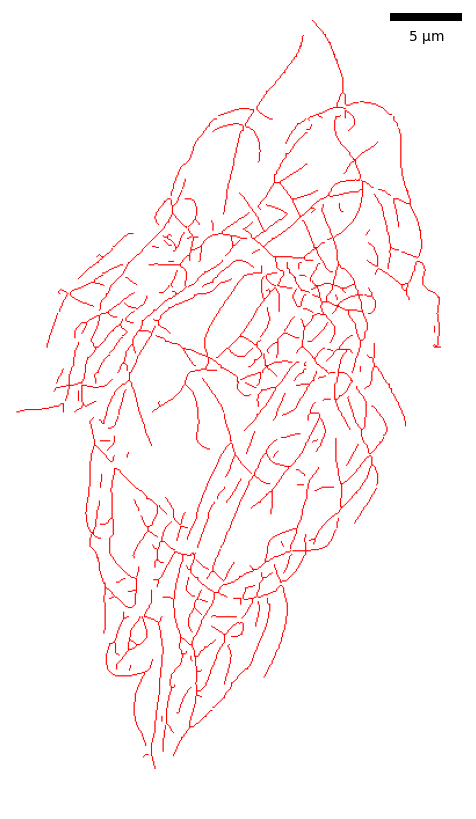

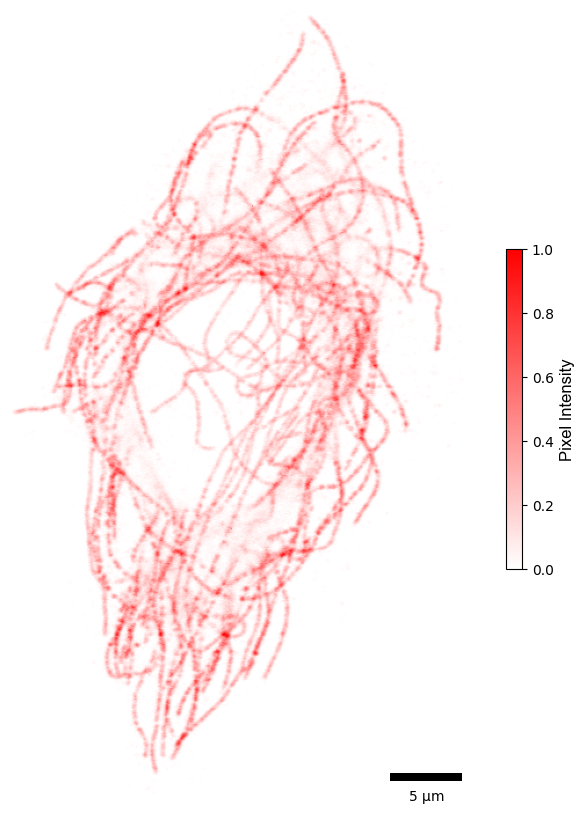

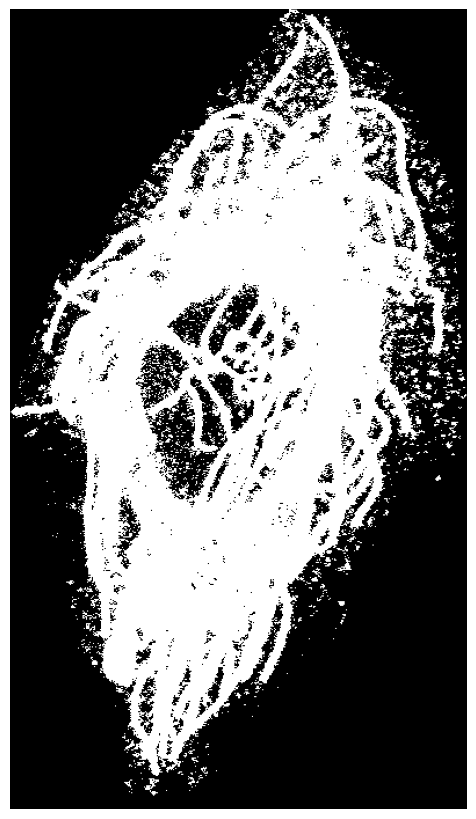

In [5]:
fig_int = intensity_plotter(ResultsRow = ResultsDF.loc[cell],
                            data       = data,
                            save       = False)    

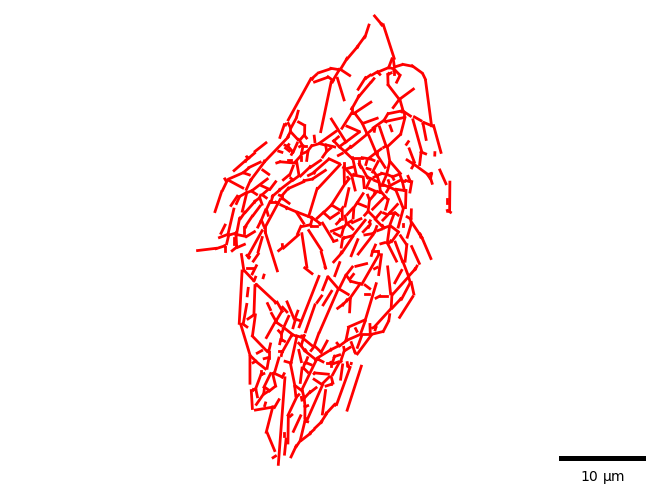

In [5]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_lines = line_plotter(ResultsRow = ResultsDF.loc[0],
                                 data=data,
                                 feat=None,
                                 cmap=cm,
                                 normalize_bounds=1,
                                 colorbar_label=None,
                                 overlay=True,
                                 save=False)

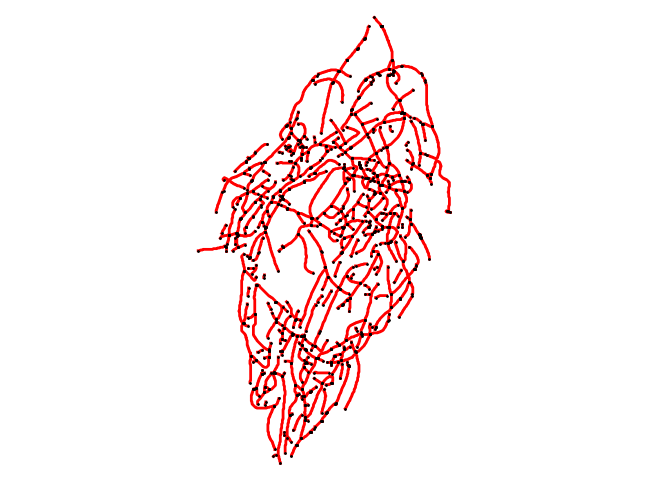

In [4]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[0],
                          data             = data,
                          feat             = None,
                          cmap             = cm,
                          normalize_bounds = 'default',
                          colorbar_label   = None,
                          nodes            = True,
                          main_branch      = False,
                          overlay          = None,
                          scalebar         = False,
                          save             = False)

In [107]:
def read_soax_txt(path):
    import pandas as pd

    # Open the file
    with open(path, 'r') as file:
        lines = file.readlines()

    filament_dataframes = []  # List to store dataframes for each filament
    current_filament_data = []  # List to store data for the current filament

    # Iterate through lines in the file
    for line in lines:
        # Ignore empty lines and lines starting with '#'
        if line.strip() == '' or line.startswith('#'):
            if current_filament_data:
                # Convert current_filament_data to a DataFrame and append it to the list
                df = pd.DataFrame(current_filament_data)
                # Remove the first row from the DataFrame
                df = df.iloc[1:]
                filament_dataframes.append(df)
                current_filament_data = []  # Reset for the next filament
        else:
            # Split the line and append it to the current_filament_data
            data = line.split()
            current_filament_data.append(data)

    # If there's remaining data after the last '#', convert it to a DataFrame and append it
    if current_filament_data:
        df = pd.DataFrame(current_filament_data)
        # Remove the first row from the DataFrame
        df = df.iloc[1:]
        filament_dataframes.append(df)

    # Access individual dataframes
    for i, df in enumerate(filament_dataframes):
        print(f'Filament {i+1} DataFrame:')
        print(df)
        print('\n')
        
    return filament_dataframes

filament_dataframes = read_soax_txt('snakes.txt')

Filament 1 DataFrame:
                                     0      1     2     3     4     5     6   \
1                     intensity-scaling      0  None  None  None  None  None   
2                          gaussian-std      0  None  None  None  None  None   
3                       ridge-threshold   0.01  None  None  None  None  None   
4                    maximum-foreground  65535  None  None  None  None  None   
5                    minimum-foreground      0  None  None  None  None  None   
6                                init-z   true  None  None  None  None  None   
7                   snake-point-spacing      1  None  None  None  None  None   
8                  minimum-snake-length      4  None  None  None  None  None   
9                    maximum-iterations  10000  None  None  None  None  None   
10                     change-threshold    0.1  None  None  None  None  None   
11                         check-period    100  None  None  None  None  None   
12                

     0   1        2        3  4        5        6
1   86   1  340.244  486.009  0  10396.5        0
2   86   2  340.088  486.999  0    12326        0
3   86   3  339.989  487.997  0  16063.2        0
4   86   4  339.871  488.992  0  11383.6        0
5   86   5  339.662  489.973  0  8197.97        0
6   86   6  339.353  490.926  0     9975        0
7   86   7  339.134  491.905  0  13636.5        0
8   86   8  339.036  492.903  0  17692.9        0
9   86   9  338.985  493.904  0  21235.2        0
10  86  10    338.9  494.903  0  14388.5        0
11  86  11  338.707  495.887  0  12418.1        0
12  86  12  338.404  496.842  0  6247.85        0
13  86  13  338.165  497.816  0   8353.7        0
14  86  14  338.032   498.81  0  7784.08        0
15  86  15  337.925  499.807  0  9240.36        0
16  86  16  337.745  500.793  0  8632.52        0
17  86  17   337.48   501.76  0  4490.61        0
18  86  18  337.244  502.734  0  7785.24        0
19  86  19  337.052  503.718  0  10667.8        0


      0   1        2        3  4        5        6
1   184   1  299.922  359.536  0  23459.3        0
2   184   2  300.153  360.501  0  19207.9        0
3   184   3  300.428  361.454  0  11199.3        0
4   184   4  300.722  362.401  0  18505.9        0
5   184   5  301.015  363.349  0    37389        0
6   184   6  301.366  364.277  0  26548.5        0
7   184   7  301.752  365.191  0  35832.3        0
8   184   8  301.993  366.153  0  48100.2        0
9   184   9   302.13  367.136  0  35351.9        0
10  184  10  302.354  368.102  0  22084.6        0
11  184  11  302.689  369.036  0  27200.4        0
12  184  12  302.908  370.004  0    43473        0
13  184  13  303.045  370.986  0  52238.2        0
14  184  14  303.296  371.946  0  31268.1        0
15  184  15  303.678  372.862  0  23095.3        0
16  184  16  304.119  373.751  0  36921.3        0
17  184  17   304.55  374.644  0  22259.5  2204.33
18  184  18  304.898  375.573  0  37560.9  4648.42
19  184  19  305.188  376.522  

In [113]:
filament_dataframes[-1]

,0,1,2,3,4,5,6
1,229,1,67.1682,394.249,0,7190.68,1709.69
2,229,2,67.6633,395.091,0,11472.6,2064.07
3,229,3,68.1594,395.933,0,21622.6,2874.68
4,229,4,68.6341,396.787,0,12501.2,1288.12
5,229,5,69.0932,397.65,0,19050.7,1354.47
...,...,...,...,...,...,...,...
173,"[94.882,","274.876,",0],None,None,None,None
174,"[103.628,","147.802,",0],None,None,None,None
175,"[203.693,","165.043,",0],None,None,None,None
176,"[132.332,","207.158,",0],None,None,None,None


In [119]:
def read_junctions():
    import pandas as pd

    # Read the file line-by-line and reverse the order
    with open('snakes.txt', 'r') as file:
        lines = file.readlines()[::-1]

    # Collect lines that contain lists and stop when the pattern no longer matches
    coordinate_lines = []
    for line in lines:
        line = line.strip()
        # Check if line looks like a list (starts and ends with square brackets)
        if line.startswith('[') and line.endswith(']'):
            coordinate_lines.append(line)
        else:
            break

    # Reverse the list to restore the original order and create a DataFrame
    coordinate_lines.reverse()
    junctionsdf = pd.DataFrame([eval(line) for line in coordinate_lines], columns=['X', 'Y', 'Z'])

    return junctionsdf

junctionsdf = read_junctions()

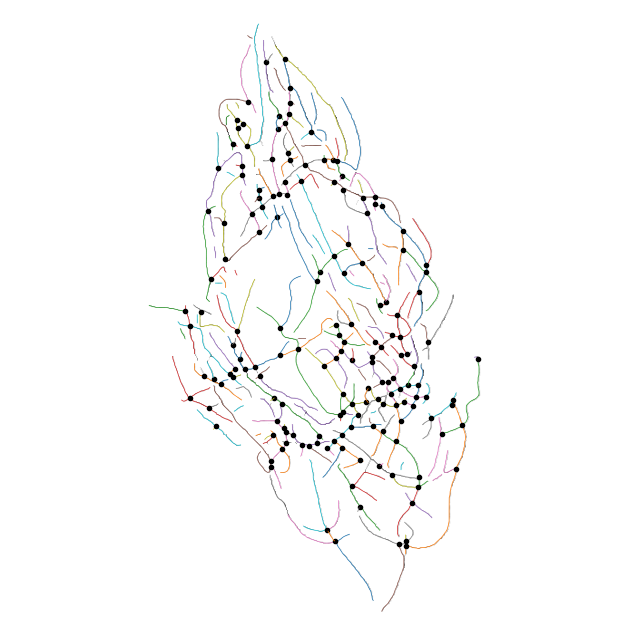

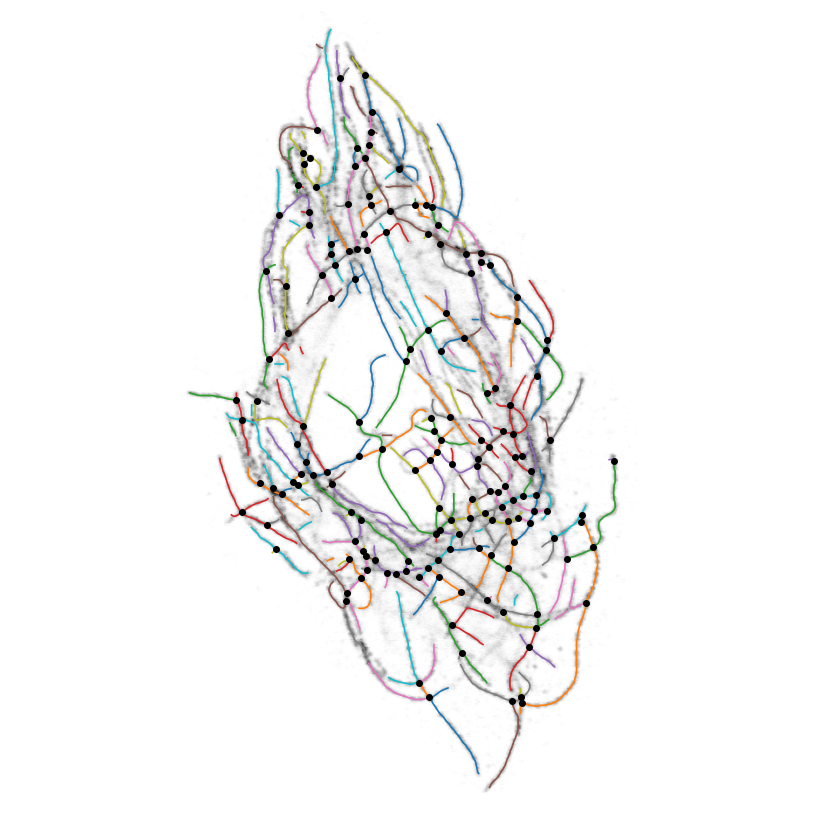

In [137]:
def plot_soax(imgorig,skel,filament_df,junctionsdf):
    
    fig,ax = plt.subplots(figsize=(8,8))
    fig2,ax2 = plt.subplots(figsize=(8,8))
    ax.imshow(np.max(skel)-skel,cmap='gray',alpha=1,zorder=1)
    ax2.imshow(imgorig,cmap='gray')
    ax.axis('off')
    ax2.axis('off')
    ax.axis('equal')
    ax2.axis('equal')
    
    zorder = 2
    # PLOT FILAMENT
    for filament in filament_df[2:-1]:
        x = []
        y = []
        x = [float(a) for a in filament[2]] 
        y = [float(b) for b in filament[3]]
            
        
        ax.plot(x,y,linewidth=0.5,zorder=zorder)
        ax2.plot(x,y,linewidth=1.2,zorder=zorder)
        zorder += 1
    
    # PLOT JUNCTION
    for index,row in junctionsdf.iterrows():
        ax.plot(row[0],row[1],'ko',zorder=200,markersize=3)
        ax2.plot(row[0],row[1],'ko',zorder=300,markersize=4)
    
    plt.tight_layout(pad=0)
    fig.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("skelsoax") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    fig2.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("origsoax") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    
    
    
    plt.show()
                    

plot_soax(np.max(imagens[0]) - imagens[0][180:860,0:400],skelorig,filament_dataframes,junctionsdf)

<div class="alert alert-block alert-info">
    
 **SAVE DATAFRAME FOR FEATURE EXTRACTION**
    
</div>

In [14]:
ResultsDF.to_pickle(folder + '//ResultsDF_TEST2.pkl')   

---